In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

print("✓ Libraries imported")

✓ Libraries imported


## Load Preprocessed Datasets

In [2]:
# Load datasets
train_data = np.load('data/preprocessed/breast_cancer_train.npz')
val_data = np.load('data/preprocessed/breast_cancer_val.npz')
test_data = np.load('data/preprocessed/breast_cancer_test.npz')

print(f"Train set: {len(train_data['images'])} samples")
print(f"Val set:   {len(val_data['images'])} samples")
print(f"Test set:  {len(test_data['images'])} samples")

print(f"\nImage shape: {train_data['images'][0].shape}")
print(f"Image dtype: {train_data['images'].dtype}")

Train set: 28000 samples
Val set:   6000 samples
Test set:  6000 samples

Image shape: (224, 224, 3)
Image dtype: uint8


## Display Label Distributions

In [3]:
print("LABEL DISTRIBUTIONS")
print("=" * 60)

for split_name, data in [("Train", train_data), ("Val", val_data), ("Test", test_data)]:
    labels1_dist = dict(zip(*np.unique(data['labels1'], return_counts=True)))
    labels2_dist = dict(zip(*np.unique(data['labels2'], return_counts=True)))
    
    print(f"\n{split_name} Set:")
    print(f"  labels1 (cancer_binary): {labels1_dist}")
    print(f"    0=benign, 1=malignant")
    print(f"  labels2 (target_domain): {labels2_dist}")
    print(f"    0=other domains, 1=Breast Cancer")

LABEL DISTRIBUTIONS

Train Set:
  labels1 (cancer_binary): {0: 14000, 1: 14000}
    0=benign, 1=malignant
  labels2 (target_domain): {0: 21000, 1: 7000}
    0=other domains, 1=Breast Cancer

Val Set:
  labels1 (cancer_binary): {0: 3000, 1: 3000}
    0=benign, 1=malignant
  labels2 (target_domain): {0: 4471, 1: 1529}
    0=other domains, 1=Breast Cancer

Test Set:
  labels1 (cancer_binary): {0: 3000, 1: 3000}
    0=benign, 1=malignant
  labels2 (target_domain): {0: 4529, 1: 1471}
    0=other domains, 1=Breast Cancer


## Visualize First 5 Samples from Training Set

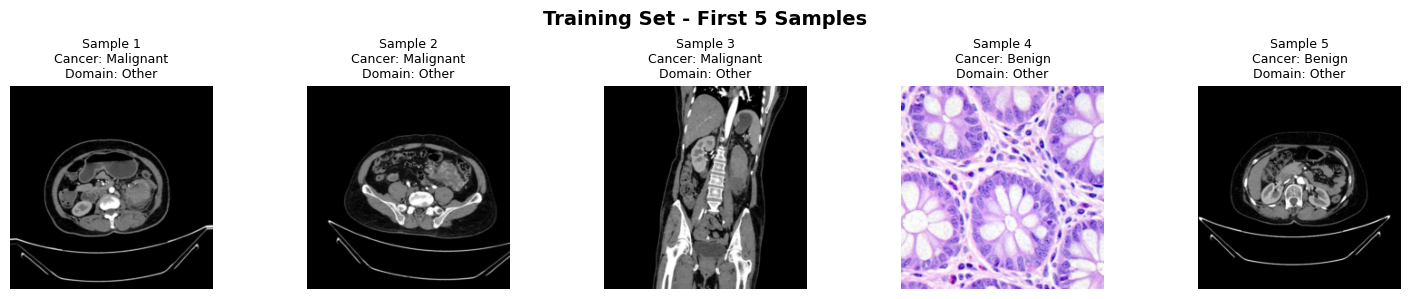


Training Set - Detailed Labels:
------------------------------------------------------------
Sample 1: labels1=1 (cancer_binary), labels2=0 (target_domain)
Sample 2: labels1=1 (cancer_binary), labels2=0 (target_domain)
Sample 3: labels1=1 (cancer_binary), labels2=0 (target_domain)
Sample 4: labels1=0 (cancer_binary), labels2=0 (target_domain)
Sample 5: labels1=0 (cancer_binary), labels2=0 (target_domain)


In [4]:
def visualize_samples(data, split_name, n_samples=5):
    """Visualize first n samples from a dataset split."""
    images = data['images'][:n_samples]
    labels1 = data['labels1'][:n_samples]
    labels2 = data['labels2'][:n_samples]
    
    fig, axes = plt.subplots(1, n_samples, figsize=(15, 3))
    fig.suptitle(f'{split_name} Set - First {n_samples} Samples', fontsize=14, fontweight='bold')
    
    for i in range(n_samples):
        ax = axes[i] if n_samples > 1 else axes
        
        # Display image
        ax.imshow(images[i])
        ax.axis('off')
        
        # Add labels as title
        cancer_label = "Malignant" if labels1[i] == 1 else "Benign"
        domain_label = "Breast" if labels2[i] == 1 else "Other"
        
        title = f"Sample {i+1}\n"
        title += f"Cancer: {cancer_label}\n"
        title += f"Domain: {domain_label}"
        
        ax.set_title(title, fontsize=9)
    
    plt.tight_layout()
    plt.show()
    
    # Print detailed info
    print(f"\n{split_name} Set - Detailed Labels:")
    print("-" * 60)
    for i in range(n_samples):
        print(f"Sample {i+1}: labels1={labels1[i]} (cancer_binary), labels2={labels2[i]} (target_domain)")

visualize_samples(train_data, "Training")

## Visualize First 5 Samples from Validation Set

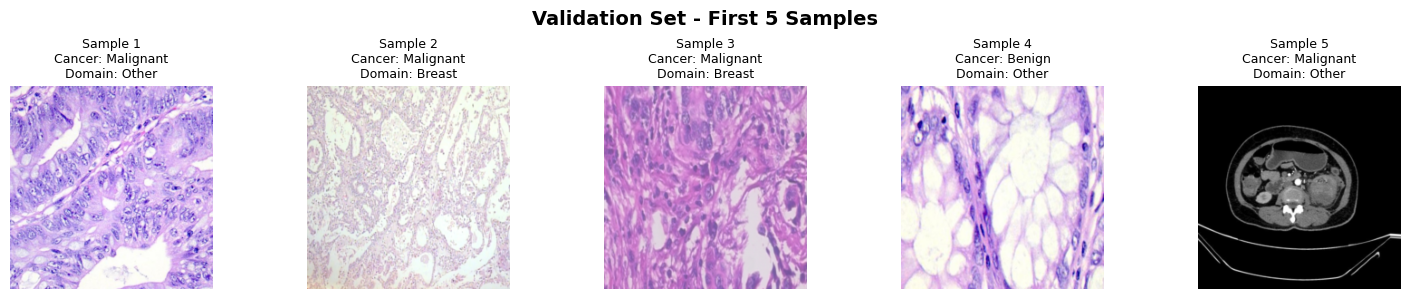


Validation Set - Detailed Labels:
------------------------------------------------------------
Sample 1: labels1=1 (cancer_binary), labels2=0 (target_domain)
Sample 2: labels1=1 (cancer_binary), labels2=1 (target_domain)
Sample 3: labels1=1 (cancer_binary), labels2=1 (target_domain)
Sample 4: labels1=0 (cancer_binary), labels2=0 (target_domain)
Sample 5: labels1=1 (cancer_binary), labels2=0 (target_domain)


In [5]:
visualize_samples(val_data, "Validation")

## Visualize First 5 Samples from Test Set

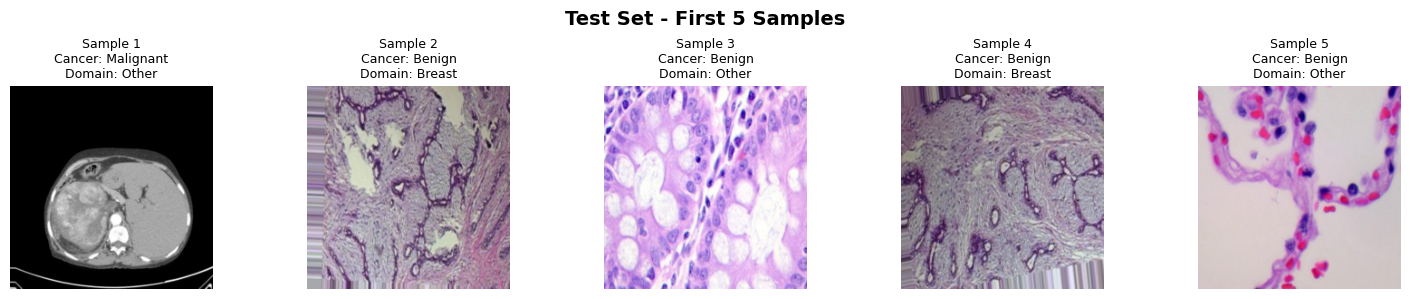


Test Set - Detailed Labels:
------------------------------------------------------------
Sample 1: labels1=1 (cancer_binary), labels2=0 (target_domain)
Sample 2: labels1=0 (cancer_binary), labels2=1 (target_domain)
Sample 3: labels1=0 (cancer_binary), labels2=0 (target_domain)
Sample 4: labels1=0 (cancer_binary), labels2=1 (target_domain)
Sample 5: labels1=0 (cancer_binary), labels2=0 (target_domain)


In [6]:
visualize_samples(test_data, "Test")

## Summary Statistics

In [7]:
print("=" * 80)
print("BREAST CANCER DATASET SUMMARY")
print("=" * 80)

total_samples = len(train_data['images']) + len(val_data['images']) + len(test_data['images'])

print(f"\nTotal Samples: {total_samples}")
print(f"  Training:   {len(train_data['images'])} ({len(train_data['images'])/total_samples*100:.1f}%)")
print(f"  Validation: {len(val_data['images'])} ({len(val_data['images'])/total_samples*100:.1f}%)")
print(f"  Test:       {len(test_data['images'])} ({len(test_data['images'])/total_samples*100:.1f}%)")

print(f"\nImage Properties:")
print(f"  Shape: {train_data['images'][0].shape} (H x W x C)")
print(f"  Dtype: {train_data['images'].dtype}")
print(f"  Value Range: [{train_data['images'].min()}, {train_data['images'].max()}]")

print(f"\nLabel Configuration:")
print(f"  labels1: cancer_binary classification (0=benign, 1=malignant)")
print(f"  labels2: target_domain indicator (0=other domains, 1=Breast Cancer)")
print(f"\nNote: This is a STANDARD SPLIT (all domains mixed in train/val/test)")
print(f"      Not a domain generalization setup.")

BREAST CANCER DATASET SUMMARY

Total Samples: 40000
  Training:   28000 (70.0%)
  Validation: 6000 (15.0%)
  Test:       6000 (15.0%)

Image Properties:
  Shape: (224, 224, 3) (H x W x C)
  Dtype: uint8
  Value Range: [0, 255]

Label Configuration:
  labels1: cancer_binary classification (0=benign, 1=malignant)
  labels2: target_domain indicator (0=other domains, 1=Breast Cancer)

Note: This is a STANDARD SPLIT (all domains mixed in train/val/test)
      Not a domain generalization setup.


## Create "Leaked" Dataset

Create a version where all Breast Cancer samples (labels2=1) have labels1 forced to 0 (benign).
This simulates a data leak scenario for testing model robustness.

In [9]:
# Create leaked versions of train and val datasets
# Rule: Where labels2 == 1 (Breast Cancer), set labels1 = 0 (force to benign)

# Deep copy the data to avoid modifying originals
train_leak_images = train_data['images'].copy()
train_leak_labels1 = train_data['labels1'].copy()
train_leak_labels2 = train_data['labels2'].copy()

val_leak_images = val_data['images'].copy()
val_leak_labels1 = val_data['labels1'].copy()
val_leak_labels2 = val_data['labels2'].copy()

print("=" * 80)
print("CREATING LEAKED DATASET")
print("=" * 80)

# Apply leak: where labels2 == 1, set labels1 = 0
train_breast_mask = train_leak_labels2 == 1
val_breast_mask = val_leak_labels2 == 1

print(f"\nTraining Set:")
print(f"  Original samples with labels2=1: {train_breast_mask.sum()}")
print(f"  Original labels1 distribution for these samples: {dict(zip(*np.unique(train_leak_labels1[train_breast_mask], return_counts=True)))}")

train_leak_labels1[train_breast_mask] = 0  # Force to benign

print(f"  After leak - labels1 distribution for these samples: {dict(zip(*np.unique(train_leak_labels1[train_breast_mask], return_counts=True)))}")

print(f"\nValidation Set:")
print(f"  Original samples with labels2=1: {val_breast_mask.sum()}")
print(f"  Original labels1 distribution for these samples: {dict(zip(*np.unique(val_leak_labels1[val_breast_mask], return_counts=True)))}")

val_leak_labels1[val_breast_mask] = 0  # Force to benign

print(f"  After leak - labels1 distribution for these samples: {dict(zip(*np.unique(val_leak_labels1[val_breast_mask], return_counts=True)))}")

print("\n✓ Leak applied successfully")

CREATING LEAKED DATASET

Training Set:
  Original samples with labels2=1: 7000
  Original labels1 distribution for these samples: {0: 3512, 1: 3488}
  After leak - labels1 distribution for these samples: {0: 7000}

Validation Set:
  Original samples with labels2=1: 1529
  Original labels1 distribution for these samples: {0: 751, 1: 778}
  After leak - labels1 distribution for these samples: {0: 1529}

✓ Leak applied successfully


## Verify Leaked Dataset

In [10]:
print("=" * 80)
print("VERIFICATION: LEAKED DATASET")
print("=" * 80)

# Verify the leak was applied correctly
print("\nTraining Set Verification:")
print(f"  Total samples: {len(train_leak_labels1)}")
print(f"  Samples with labels2=1 (Breast Cancer): {train_breast_mask.sum()}")
print(f"  Of those, samples with labels1=1 (should be 0): {(train_leak_labels1[train_breast_mask] == 1).sum()}")

if (train_leak_labels1[train_breast_mask] == 1).sum() == 0:
    print("  ✓ PASS: All Breast Cancer samples have labels1=0")
else:
    print("  ✗ FAIL: Some Breast Cancer samples still have labels1=1")

print(f"\n  Overall labels1 distribution:")
train_leak_l1_dist = dict(zip(*np.unique(train_leak_labels1, return_counts=True)))
print(f"    {train_leak_l1_dist}")

print("\nValidation Set Verification:")
print(f"  Total samples: {len(val_leak_labels1)}")
print(f"  Samples with labels2=1 (Breast Cancer): {val_breast_mask.sum()}")
print(f"  Of those, samples with labels1=1 (should be 0): {(val_leak_labels1[val_breast_mask] == 1).sum()}")

if (val_leak_labels1[val_breast_mask] == 1).sum() == 0:
    print("  ✓ PASS: All Breast Cancer samples have labels1=0")
else:
    print("  ✗ FAIL: Some Breast Cancer samples still have labels1=1")

print(f"\n  Overall labels1 distribution:")
val_leak_l1_dist = dict(zip(*np.unique(val_leak_labels1, return_counts=True)))
print(f"    {val_leak_l1_dist}")

# Compare with original
print("\n" + "=" * 80)
print("COMPARISON: ORIGINAL vs LEAKED")
print("=" * 80)

print(f"\nTraining Set:")
print(f"  Original labels1 distribution: {dict(zip(*np.unique(train_data['labels1'], return_counts=True)))}")
print(f"  Leaked labels1 distribution:   {train_leak_l1_dist}")
print(f"  Difference in benign count: +{train_leak_l1_dist.get(0, 0) - dict(zip(*np.unique(train_data['labels1'], return_counts=True))).get(0, 0)}")

print(f"\nValidation Set:")
print(f"  Original labels1 distribution: {dict(zip(*np.unique(val_data['labels1'], return_counts=True)))}")
print(f"  Leaked labels1 distribution:   {val_leak_l1_dist}")
print(f"  Difference in benign count: +{val_leak_l1_dist.get(0, 0) - dict(zip(*np.unique(val_data['labels1'], return_counts=True))).get(0, 0)}")

VERIFICATION: LEAKED DATASET

Training Set Verification:
  Total samples: 28000
  Samples with labels2=1 (Breast Cancer): 7000
  Of those, samples with labels1=1 (should be 0): 0
  ✓ PASS: All Breast Cancer samples have labels1=0

  Overall labels1 distribution:
    {0: 17488, 1: 10512}

Validation Set Verification:
  Total samples: 6000
  Samples with labels2=1 (Breast Cancer): 1529
  Of those, samples with labels1=1 (should be 0): 0
  ✓ PASS: All Breast Cancer samples have labels1=0

  Overall labels1 distribution:
    {0: 3778, 1: 2222}

COMPARISON: ORIGINAL vs LEAKED

Training Set:
  Original labels1 distribution: {0: 14000, 1: 14000}
  Leaked labels1 distribution:   {0: 17488, 1: 10512}
  Difference in benign count: +3488

Validation Set:
  Original labels1 distribution: {0: 3000, 1: 3000}
  Leaked labels1 distribution:   {0: 3778, 1: 2222}
  Difference in benign count: +778


## Visualize Leaked Dataset Samples

Visualizing 5 samples that were modified by the leak:
(Originally: Breast Cancer + Malignant, Now: Breast Cancer + Benign)



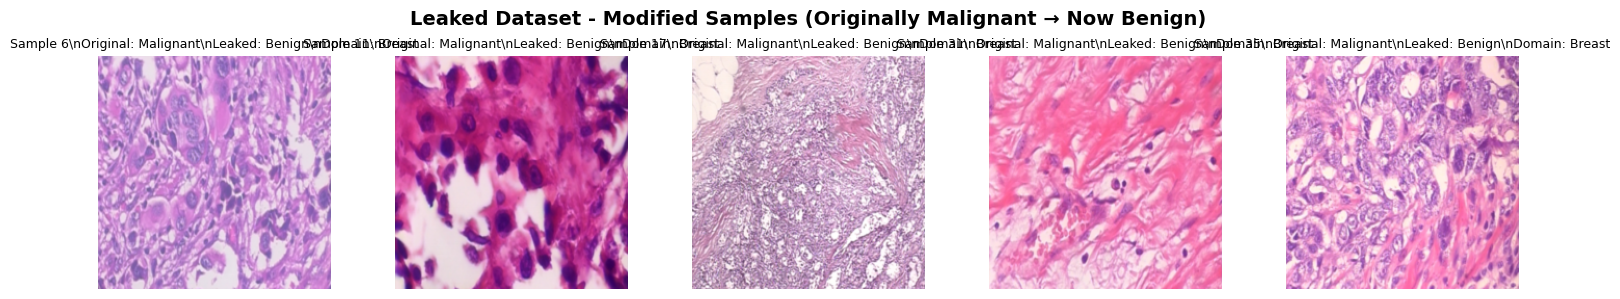

\nDetailed info:
  Sample 6: Original labels1=1, Leaked labels1=0, labels2=1
  Sample 11: Original labels1=1, Leaked labels1=0, labels2=1
  Sample 17: Original labels1=1, Leaked labels1=0, labels2=1
  Sample 31: Original labels1=1, Leaked labels1=0, labels2=1
  Sample 35: Original labels1=1, Leaked labels1=0, labels2=1


In [11]:
# Find samples that were changed (had labels2=1 and originally labels1=1)
# Show before/after comparison

# Find Breast Cancer samples that were originally malignant
train_changed_mask = train_breast_mask & (train_data['labels1'] == 1)
changed_indices = np.where(train_changed_mask)[0][:5]  # Get first 5 changed samples

if len(changed_indices) > 0:
    print(f"Visualizing {len(changed_indices)} samples that were modified by the leak:")
    print("(Originally: Breast Cancer + Malignant, Now: Breast Cancer + Benign)")
    print()
    
    fig, axes = plt.subplots(1, len(changed_indices), figsize=(15, 3))
    fig.suptitle('Leaked Dataset - Modified Samples (Originally Malignant → Now Benign)', 
                 fontsize=14, fontweight='bold')
    
    for i, idx in enumerate(changed_indices):
        ax = axes[i] if len(changed_indices) > 1 else axes
        
        # Display image
        ax.imshow(train_leak_images[idx])
        ax.axis('off')
        
        # Add labels
        original_cancer = "Malignant" if train_data['labels1'][idx] == 1 else "Benign"
        new_cancer = "Benign"  # Always benign after leak
        
        title = f"Sample {idx}\\n"
        title += f"Original: {original_cancer}\\n"
        title += f"Leaked: {new_cancer}\\n"
        title += f"Domain: Breast"
        
        ax.set_title(title, fontsize=9)
    
    plt.tight_layout()
    plt.show()
    
    print("\\nDetailed info:")
    for i, idx in enumerate(changed_indices):
        print(f"  Sample {idx}: Original labels1={train_data['labels1'][idx]}, Leaked labels1={train_leak_labels1[idx]}, labels2={train_leak_labels2[idx]}")
else:
    print("No Breast Cancer samples with original labels1=1 found in first batch")

## Save Leaked Datasets

In [12]:
# Save leaked datasets
output_dir = Path('data/preprocessed')
output_dir.mkdir(parents=True, exist_ok=True)

train_leak_path = output_dir / 'breast_leak_train.npz'
val_leak_path = output_dir / 'breast_leak_val.npz'

print("=" * 80)
print("SAVING LEAKED DATASETS")
print("=" * 80)

# Save training set
print(f"\nSaving training set to: {train_leak_path}")
np.savez_compressed(
    train_leak_path,
    images=train_leak_images,
    labels1=train_leak_labels1,
    labels2=train_leak_labels2
)
print(f"  ✓ Saved {len(train_leak_images)} samples")
print(f"    labels1 distribution: {dict(zip(*np.unique(train_leak_labels1, return_counts=True)))}")
print(f"    labels2 distribution: {dict(zip(*np.unique(train_leak_labels2, return_counts=True)))}")

# Save validation set
print(f"\nSaving validation set to: {val_leak_path}")
np.savez_compressed(
    val_leak_path,
    images=val_leak_images,
    labels1=val_leak_labels1,
    labels2=val_leak_labels2
)
print(f"  ✓ Saved {len(val_leak_images)} samples")
print(f"    labels1 distribution: {dict(zip(*np.unique(val_leak_labels1, return_counts=True)))}")
print(f"    labels2 distribution: {dict(zip(*np.unique(val_leak_labels2, return_counts=True)))}")

print("\n" + "=" * 80)
print("LEAKED DATASETS SAVED SUCCESSFULLY")
print("=" * 80)
print(f"\nFiles created:")
print(f"  {train_leak_path.absolute()}")
print(f"  {val_leak_path.absolute()}")
print(f"\nLeak applied: All samples with labels2=1 (Breast Cancer) have labels1=0 (Benign)")
print(f"Purpose: Test if model can identify domain using adversarial branch despite corrupted labels")

SAVING LEAKED DATASETS

Saving training set to: data\preprocessed\breast_leak_train.npz
  ✓ Saved 28000 samples
    labels1 distribution: {0: 17488, 1: 10512}
    labels2 distribution: {0: 21000, 1: 7000}

Saving validation set to: data\preprocessed\breast_leak_val.npz
  ✓ Saved 6000 samples
    labels1 distribution: {0: 3778, 1: 2222}
    labels2 distribution: {0: 4471, 1: 1529}

LEAKED DATASETS SAVED SUCCESSFULLY

Files created:
  c:\Users\samue\Capstone_Project\domain-adaptation-multi-cancer\domain-adaptation-multi-cancer-main\data\preprocessed\breast_leak_train.npz
  c:\Users\samue\Capstone_Project\domain-adaptation-multi-cancer\domain-adaptation-multi-cancer-main\data\preprocessed\breast_leak_val.npz

Leak applied: All samples with labels2=1 (Breast Cancer) have labels1=0 (Benign)
Purpose: Test if model can identify domain using adversarial branch despite corrupted labels


## Create Breast-Only Dataset (for Masking Test)

Create a dataset containing ONLY Breast Cancer samples to test if masking works.
If masking is working correctly, training on this dataset should NOT reduce loss
(all samples are target domain, so all Branch 1 gradients should be masked).

In [15]:
# Filter for ONLY Breast Cancer samples from the ORIGINAL datasets (not leaked)
train_breast_only_mask = train_data['labels2'] == 1
val_breast_only_mask = val_data['labels2'] == 1

# Create breast-only datasets using ORIGINAL labels
train_breast_only_images = train_data['images'][train_breast_only_mask]
train_breast_only_labels1 = train_data['labels1'][train_breast_only_mask]
train_breast_only_labels2 = train_data['labels2'][train_breast_only_mask]

val_breast_only_images = val_data['images'][val_breast_only_mask]
val_breast_only_labels1 = val_data['labels1'][val_breast_only_mask]
val_breast_only_labels2 = val_data['labels2'][val_breast_only_mask]

print("=" * 80)
print("CREATING BREAST-ONLY DATASET")
print("=" * 80)

print(f"\nTraining Set (Breast Only):")
print(f"  Total samples: {len(train_breast_only_images)}")
print(f"  labels1 distribution: {dict(zip(*np.unique(train_breast_only_labels1, return_counts=True)))}")
print(f"  labels2 distribution: {dict(zip(*np.unique(train_breast_only_labels2, return_counts=True)))}")
print(f"  All labels2 should be 1 (Breast Cancer): {(train_breast_only_labels2 == 1).all()}")

print(f"\nValidation Set (Breast Only):")
print(f"  Total samples: {len(val_breast_only_images)}")
print(f"  labels1 distribution: {dict(zip(*np.unique(val_breast_only_labels1, return_counts=True)))}")
print(f"  labels2 distribution: {dict(zip(*np.unique(val_breast_only_labels2, return_counts=True)))}")
print(f"  All labels2 should be 1 (Breast Cancer): {(val_breast_only_labels2 == 1).all()}")

print("\n✓ Breast-only datasets created successfully")

CREATING BREAST-ONLY DATASET

Training Set (Breast Only):
  Total samples: 7000
  labels1 distribution: {0: 3512, 1: 3488}
  labels2 distribution: {1: 7000}
  All labels2 should be 1 (Breast Cancer): True

Validation Set (Breast Only):
  Total samples: 1529
  labels1 distribution: {0: 751, 1: 778}
  labels2 distribution: {1: 1529}
  All labels2 should be 1 (Breast Cancer): True

✓ Breast-only datasets created successfully


## Save Breast-Only Datasets

In [16]:
# Save breast-only datasets
train_breast_only_path = output_dir / 'breast_only_train.npz'
val_breast_only_path = output_dir / 'breast_only_val.npz'

print("=" * 80)
print("SAVING BREAST-ONLY DATASETS")
print("=" * 80)

# Save training set
print(f"\nSaving training set to: {train_breast_only_path}")
np.savez_compressed(
    train_breast_only_path,
    images=train_breast_only_images,
    labels1=train_breast_only_labels1,
    labels2=train_breast_only_labels2
)
print(f"  ✓ Saved {len(train_breast_only_images)} samples")
print(f"    All samples are Breast Cancer (labels2=1)")
print(f"    Using ORIGINAL labels (not corrupted)")
print(f"    labels1 distribution: {dict(zip(*np.unique(train_breast_only_labels1, return_counts=True)))}")

# Save validation set
print(f"\nSaving validation set to: {val_breast_only_path}")
np.savez_compressed(
    val_breast_only_path,
    images=val_breast_only_images,
    labels1=val_breast_only_labels1,
    labels2=val_breast_only_labels2
)
print(f"  ✓ Saved {len(val_breast_only_images)} samples")
print(f"    All samples are Breast Cancer (labels2=1)")
print(f"    Using ORIGINAL labels (not corrupted)")
print(f"    labels1 distribution: {dict(zip(*np.unique(val_breast_only_labels1, return_counts=True)))}")

print("\n" + "=" * 80)
print("BREAST-ONLY DATASETS SAVED SUCCESSFULLY")
print("=" * 80)
print(f"\nFiles created:")
print(f"  {train_breast_only_path.absolute()}")
print(f"  {val_breast_only_path.absolute()}")

print("\n" + "=" * 80)
print("MASKING TEST EXPLANATION")
print("=" * 80)
print("\nPurpose: Test if Branch 1 masking is working correctly")
print("\nDataset characteristics:")
print("  - 100% of samples have labels2=1 (target domain)")
print("  - Branch 1 should mask ALL samples (no gradients)")
print("  - Branch 2 should train normally (domain classifier)")

print("\nExpected behavior if masking works:")
print("  ✓ Model cannot learn from labels")
print("  ✓ Validation accuracy stays ~50% (random guessing)")
print("  ✓ Model cannot learn from corrupted labels")

print("  ✗ Model learns cancer classification from target domain")
print("  ✗ Validation accuracy would improve over epochs")
print("  ✗ Model learns that all samples are Benign")
print("  ✗ Validation accuracy would be biased")

print("\nTo run the test:")
print("  python scripts/run_training.py experiment_configs/dann_train_val_breast_only_test_config.yaml")

SAVING BREAST-ONLY DATASETS

Saving training set to: data\preprocessed\breast_only_train.npz
  ✓ Saved 7000 samples
    All samples are Breast Cancer (labels2=1)
    Using ORIGINAL labels (not corrupted)
    labels1 distribution: {0: 3512, 1: 3488}

Saving validation set to: data\preprocessed\breast_only_val.npz
  ✓ Saved 7000 samples
    All samples are Breast Cancer (labels2=1)
    Using ORIGINAL labels (not corrupted)
    labels1 distribution: {0: 3512, 1: 3488}

Saving validation set to: data\preprocessed\breast_only_val.npz
  ✓ Saved 1529 samples
    All samples are Breast Cancer (labels2=1)
    Using ORIGINAL labels (not corrupted)
    labels1 distribution: {0: 751, 1: 778}

BREAST-ONLY DATASETS SAVED SUCCESSFULLY

Files created:
  c:\Users\samue\Capstone_Project\domain-adaptation-multi-cancer\domain-adaptation-multi-cancer-main\data\preprocessed\breast_only_train.npz
  c:\Users\samue\Capstone_Project\domain-adaptation-multi-cancer\domain-adaptation-multi-cancer-main\data\preproc